STEP 1: DATA LOADING AND INITIAL ANALYSIS

[1.1] Loading dataset from UCI repository...
✓ Dataset loaded successfully from UCI repository

Dataset shape: (581012, 55)
Number of samples: 581012
Number of features: 54
Number of classes: 7

[1.2] First 5 rows of the dataset:
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                       

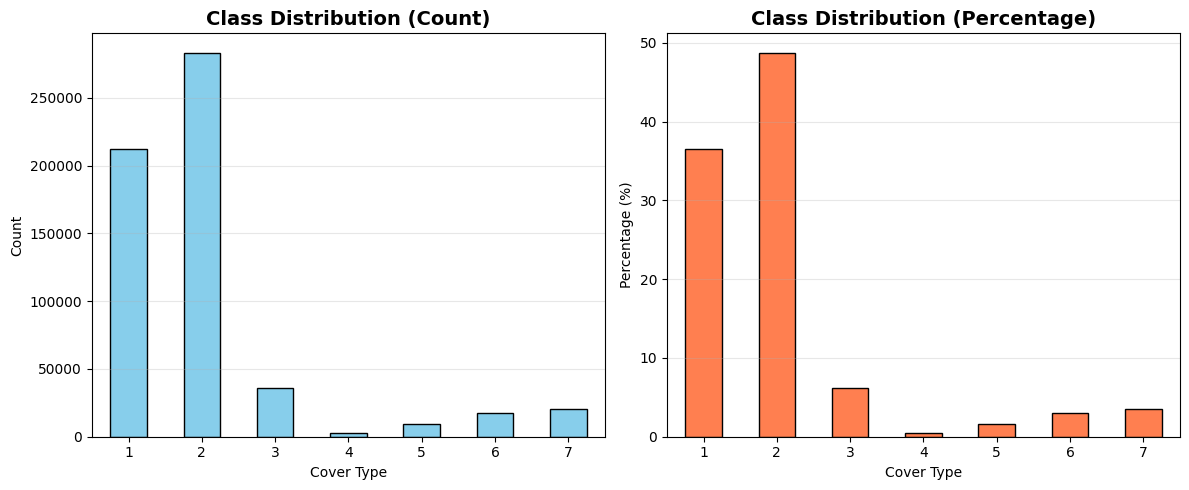


[1.6] Feature type analysis:
Numerical features: 10 (18.5%)
Wilderness Area (binary): 4 (7.4%)
Soil Type (binary): 40 (74.1%)

[1.7] Variance and scale analysis of numerical features:
                           Feature        Mean         Std  Min  Max  Range
                         Elevation 2959.365301  279.984734 1859 3858   1999
                            Aspect  155.656807  111.913721    0  360    360
                             Slope   14.103704    7.488242    0   66     66
  Horizontal_Distance_To_Hydrology  269.428217  212.549356    0 1397   1397
    Vertical_Distance_To_Hydrology   46.418855   58.295232 -173  601    774
   Horizontal_Distance_To_Roadways 2350.146611 1559.254870    0 7117   7117
                     Hillshade_9am  212.146049   26.769889    0  254    254
                    Hillshade_Noon  223.318716   19.768697    0  254    254
                     Hillshade_3pm  142.528263   38.274529    0  254    254
Horizontal_Distance_To_Fire_Points 1980.291226 1324.195

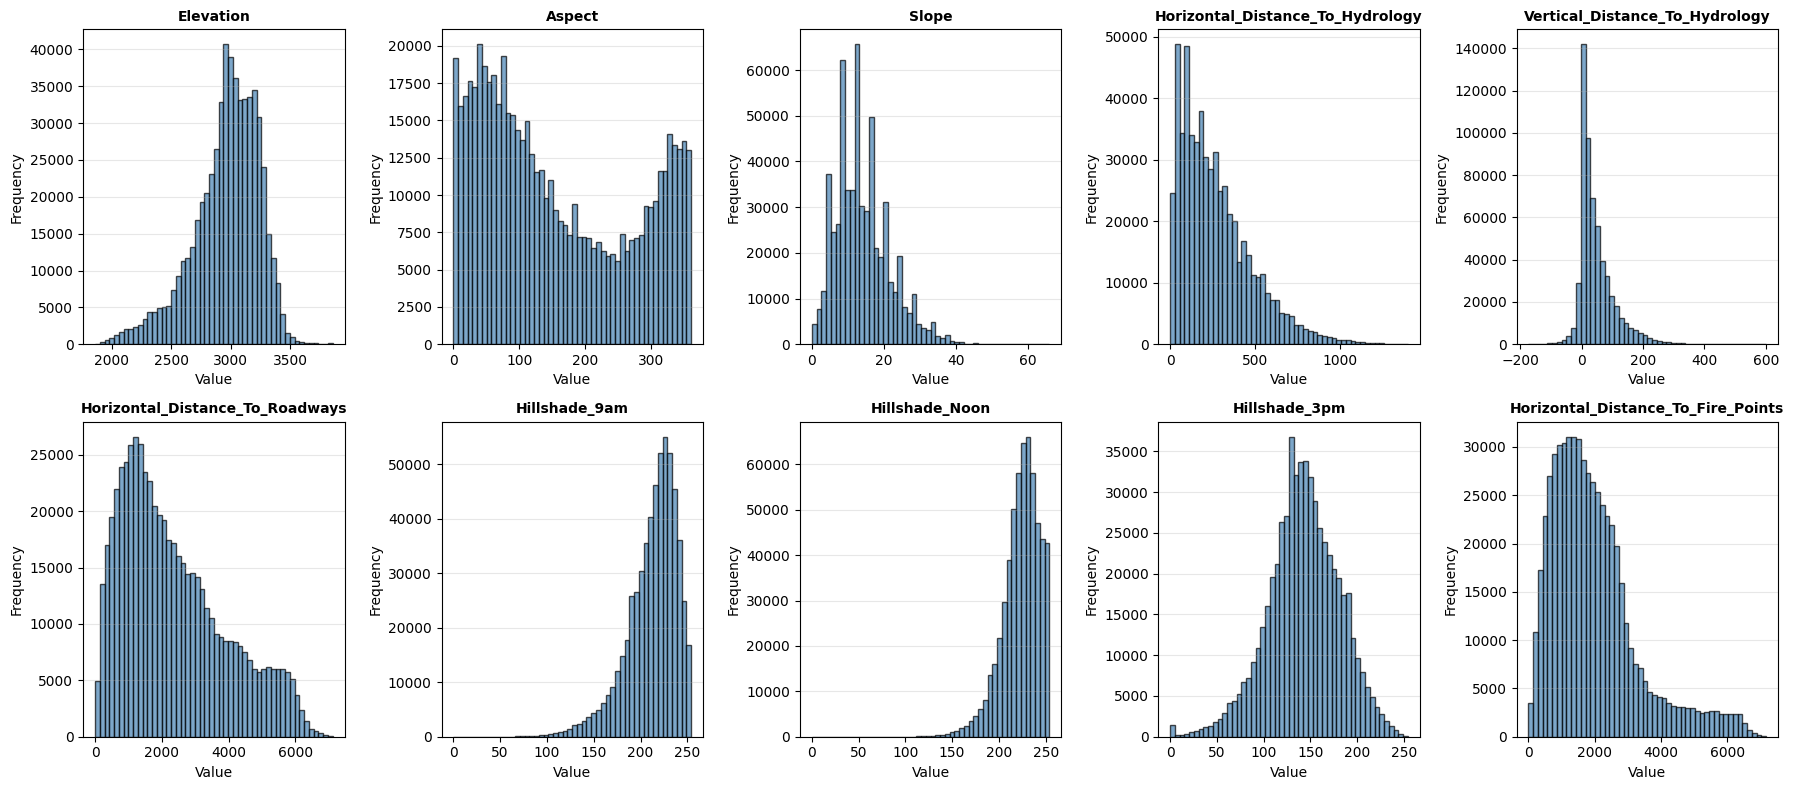


ANALYSIS COMPLETE - Answers to Questions:

1-1: Using accuracy on imbalanced data is problematic because:
     - A model predicting only the majority class can achieve high accuracy
     - Minority classes (e.g., class 4, 5) are ignored
     - Solution: Use Macro-F1, Macro-Recall, Macro-Precision and Confusion Matrix

1-2: Feature composition:
     - Numerical features: 10 (18.5%) - terrain characteristics (elevation, slope, etc.)
     - Binary features: 44 (81.5%) - categorical encoding (4 wilderness + 40 soil types)

1-3: Features with different scales/variance:
     - Elevation: range ~2000-4000, high variance
     - Distance features: range 0-7000+, very high variance
     - Hillshade features: range 0-255, moderate variance
     - Aspect/Slope: smaller ranges
     → Standardization is necessary!



In [2]:
# Step 1: Data Loading and Initial Analysis
# GPU Impact: NONE - This is pure data manipulation, CPU only

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("=" * 80)
print("STEP 1: DATA LOADING AND INITIAL ANALYSIS")
print("=" * 80)

# Alternative 1: Load from UCI repository directly
print("\n[1.1] Loading dataset from UCI repository...")

try:
    # Try loading from URL
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

    # Column names for the dataset
    feature_names = ['Elevation', 'Aspect', 'Slope',
                     'Horizontal_Distance_To_Hydrology',
                     'Vertical_Distance_To_Hydrology',
                     'Horizontal_Distance_To_Roadways',
                     'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                     'Horizontal_Distance_To_Fire_Points']

    # Add wilderness area columns
    for i in range(1, 5):
        feature_names.append(f'Wilderness_Area_{i}')

    # Add soil type columns
    for i in range(1, 41):
        feature_names.append(f'Soil_Type_{i}')

    feature_names.append('Cover_Type')

    # Load the data
    df = pd.read_csv(url, header=None, names=feature_names)

    print(f"✓ Dataset loaded successfully from UCI repository")

except Exception as e:
    print(f"Error loading from UCI: {e}")
    print("\nAlternative 2: Using local file or manual download...")
    print("Please download the dataset from:")
    print("https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz")
    print("\nOr use Kaggle: https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset")

    # For demonstration, create a small sample dataset
    print("\n⚠ Creating a small synthetic dataset for demonstration...")

    from sklearn.datasets import make_classification

    # Create synthetic data with similar characteristics
    X_temp, y_temp = make_classification(
        n_samples=10000,
        n_features=54,
        n_informative=20,
        n_redundant=10,
        n_repeated=0,
        n_classes=7,
        n_clusters_per_class=2,
        weights=[0.36, 0.49, 0.06, 0.005, 0.016, 0.03, 0.03],
        random_state=42
    )

    # Create feature names
    feature_names = ['Elevation', 'Aspect', 'Slope',
                     'Horizontal_Distance_To_Hydrology',
                     'Vertical_Distance_To_Hydrology',
                     'Horizontal_Distance_To_Roadways',
                     'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                     'Horizontal_Distance_To_Fire_Points']

    for i in range(1, 5):
        feature_names.append(f'Wilderness_Area_{i}')

    for i in range(1, 41):
        feature_names.append(f'Soil_Type_{i}')

    df = pd.DataFrame(X_temp, columns=feature_names)
    df['Cover_Type'] = y_temp + 1  # Classes 1-7

    # Scale numerical features to realistic ranges
    df['Elevation'] = (df['Elevation'] * 500 + 3000).astype(int)
    df['Aspect'] = (df['Aspect'] * 180).astype(int)
    df['Slope'] = (df['Slope'].abs() * 30).astype(int)
    df['Horizontal_Distance_To_Hydrology'] = (df['Horizontal_Distance_To_Hydrology'].abs() * 500).astype(int)
    df['Vertical_Distance_To_Hydrology'] = (df['Vertical_Distance_To_Hydrology'] * 200).astype(int)
    df['Horizontal_Distance_To_Roadways'] = (df['Horizontal_Distance_To_Roadways'].abs() * 2000).astype(int)
    df['Hillshade_9am'] = ((df['Hillshade_9am'] + 3) * 40).clip(0, 255).astype(int)
    df['Hillshade_Noon'] = ((df['Hillshade_Noon'] + 3) * 40).clip(0, 255).astype(int)
    df['Hillshade_3pm'] = ((df['Hillshade_3pm'] + 3) * 40).clip(0, 255).astype(int)
    df['Horizontal_Distance_To_Fire_Points'] = (df['Horizontal_Distance_To_Fire_Points'].abs() * 2000).astype(int)

    # Make wilderness and soil binary
    wilderness_cols = [f'Wilderness_Area_{i}' for i in range(1, 5)]
    soil_cols = [f'Soil_Type_{i}' for i in range(1, 41)]

    for col in wilderness_cols + soil_cols:
        df[col] = (df[col] > df[col].median()).astype(int)

    print("✓ Synthetic dataset created for demonstration")

# Continue with analysis
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

print(f"\nDataset shape: {df.shape}")
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(X.columns)}")
print(f"Number of classes: {y.nunique()}")

# Display first few rows
print("\n[1.2] First 5 rows of the dataset:")
print(df.head())

# Statistical summary
print("\n[1.3] Statistical summary of numerical features:")
numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                  'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                  'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                  'Horizontal_Distance_To_Fire_Points']
print(df[numerical_cols].describe())

# Check for missing values
print("\n[1.4] Missing values:")
print(f"Total missing values: {df.isnull().sum().sum()}")

# Class distribution analysis
print("\n[1.5] Class distribution:")
class_counts = df['Cover_Type'].value_counts().sort_index()
print(class_counts)
print("\nClass percentages:")
class_percentages = (class_counts / len(df) * 100).round(2)
print(class_percentages)

# Visualize class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
class_percentages.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
plt.xlabel('Cover Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze feature types
wilderness_cols = [col for col in df.columns if 'Wilderness_Area' in col]
soil_cols = [col for col in df.columns if 'Soil_Type' in col]

print("\n[1.6] Feature type analysis:")
print(f"Numerical features: {len(numerical_cols)} ({len(numerical_cols)/len(X.columns)*100:.1f}%)")
print(f"Wilderness Area (binary): {len(wilderness_cols)} ({len(wilderness_cols)/len(X.columns)*100:.1f}%)")
print(f"Soil Type (binary): {len(soil_cols)} ({len(soil_cols)/len(X.columns)*100:.1f}%)")

# Analyze variance and scale of numerical features
print("\n[1.7] Variance and scale analysis of numerical features:")
variance_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Mean': df[numerical_cols].mean().values,
    'Std': df[numerical_cols].std().values,
    'Min': df[numerical_cols].min().values,
    'Max': df[numerical_cols].max().values,
    'Range': (df[numerical_cols].max() - df[numerical_cols].min()).values
})
print(variance_df.to_string(index=False))

# Visualize numerical feature distributions
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE - Answers to Questions:")
print("=" * 80)
print("""
1-1: Using accuracy on imbalanced data is problematic because:
     - A model predicting only the majority class can achieve high accuracy
     - Minority classes (e.g., class 4, 5) are ignored
     - Solution: Use Macro-F1, Macro-Recall, Macro-Precision and Confusion Matrix

1-2: Feature composition:
     - Numerical features: 10 (18.5%) - terrain characteristics (elevation, slope, etc.)
     - Binary features: 44 (81.5%) - categorical encoding (4 wilderness + 40 soil types)

1-3: Features with different scales/variance:
     - Elevation: range ~2000-4000, high variance
     - Distance features: range 0-7000+, very high variance
     - Hillshade features: range 0-255, moderate variance
     - Aspect/Slope: smaller ranges
     → Standardization is necessary!
""")

STEP 2: DATA PREPROCESSING

[2.1] Original data shape: X=(581012, 54), y=(581012,)

[2.2] Splitting data (60% train, 20% validation, 20% test)...
Train set: 348607 samples (60.0%)
Validation set: 116202 samples (20.0%)
Test set: 116203 samples (20.0%)

[2.3] Class distribution verification:

Train set:
  Class 1: 36.46%
  Class 2: 48.76%
  Class 3: 6.15%
  Class 4: 0.47%
  Class 5: 1.63%
  Class 6: 2.99%
  Class 7: 3.53%

Validation set:
  Class 1: 36.46%
  Class 2: 48.76%
  Class 3: 6.15%
  Class 4: 0.47%
  Class 5: 1.63%
  Class 6: 2.99%
  Class 7: 3.53%

Test set:
  Class 1: 36.46%
  Class 2: 48.76%
  Class 3: 6.15%
  Class 4: 0.47%
  Class 5: 1.63%
  Class 6: 2.99%
  Class 7: 3.53%

[2.4] Standardizing features...
Important: Scaler is fit ONLY on training data to prevent data leakage!
✓ Standardization complete.

[2.5] Comparison of feature statistics (Train set):

Before standardization (first 5 features):
           Elevation         Aspect          Slope   H_Dist_Hydro  \
count 

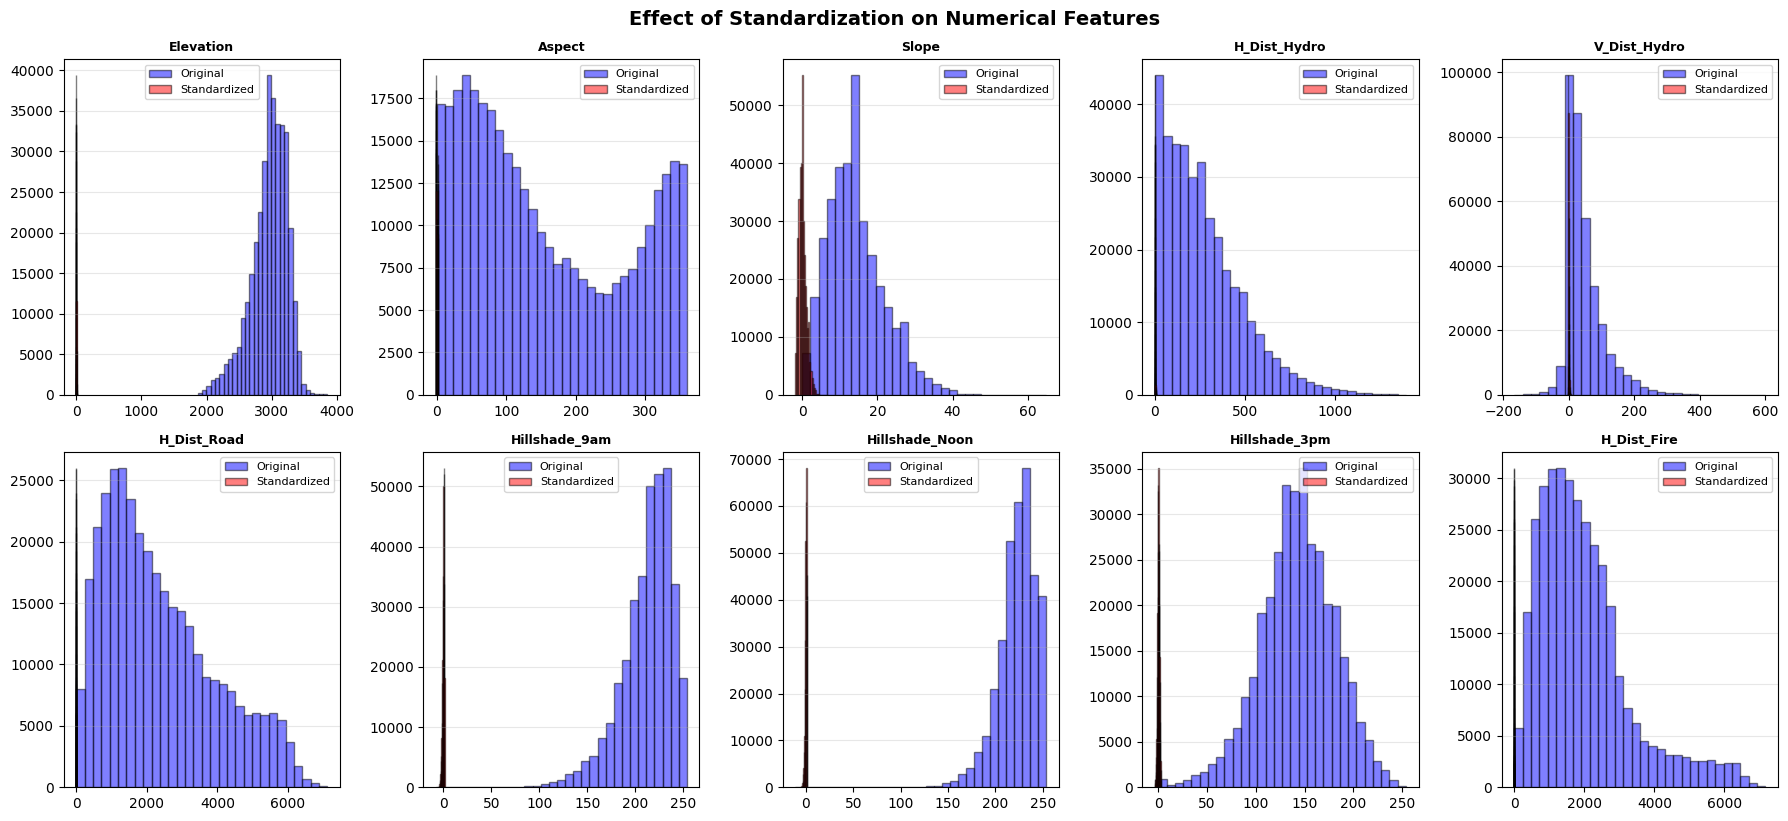


[2.6] Data leakage prevention check:
Train mean (feature 0): -0.000000 (should be ~0)
Train std (feature 0): 1.000000 (should be ~1)
Val mean (feature 0): -0.002759 (NOT necessarily 0)
Val std (feature 0): 1.001332 (NOT necessarily 1)
Test mean (feature 0): -0.000808 (NOT necessarily 0)
Test std (feature 0): 0.998934 (NOT necessarily 1)

PREPROCESSING COMPLETE - Answers to Questions:

2-1: Why do we need a validation set?
     - Train: Used to fit model parameters
     - Validation: Used to tune hyperparameters (k, max_depth) and select best model
     - Test: Used ONLY for final evaluation (never for decisions during training)
     - Without validation: We'd tune on test set → overfitting to test → invalid evaluation

2-2: Does Forest Cover Type need standardization?
     - YES! Numerical features have vastly different scales:
       * Elevation: ~2000-4000
       * Distance to hydrology: 0-7000+
       * Hillshade: 0-255
     - k-NN uses distance metrics → large-scale features domin

In [3]:
# Step 2: Data Preprocessing
# GPU Impact: NONE - Standardization and splitting are CPU operations

from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("STEP 2: DATA PREPROCESSING")
print("=" * 80)

# Separate features and target from the df created in Step 1
X = df.drop('Cover_Type', axis=1).values
y = df['Cover_Type'].values

print(f"\n[2.1] Original data shape: X={X.shape}, y={y.shape}")

# Split data: 60% train, 20% validation, 20% test
print("\n[2.2] Splitting data (60% train, 20% validation, 20% test)...")

# First split: 60% train, 40% temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Second split: 50% of temp = 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution in each set
print("\n[2.3] Class distribution verification:")
for name, y_set in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    unique, counts = np.unique(y_set, return_counts=True)
    percentages = counts / len(y_set) * 100
    print(f"\n{name} set:")
    for cls, pct in zip(unique, percentages):
        print(f"  Class {cls}: {pct:.2f}%")

# Standardization (fit only on train, transform all sets)
print("\n[2.4] Standardizing features...")
print("Important: Scaler is fit ONLY on training data to prevent data leakage!")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Standardization complete.")

# Compare before and after standardization
print("\n[2.5] Comparison of feature statistics (Train set):")
print("\nBefore standardization (first 5 features):")
print(pd.DataFrame(X_train[:, :5], columns=['Elevation', 'Aspect', 'Slope', 'H_Dist_Hydro', 'V_Dist_Hydro']).describe())

print("\nAfter standardization (first 5 features):")
print(pd.DataFrame(X_train_scaled[:, :5], columns=['Elevation', 'Aspect', 'Slope', 'H_Dist_Hydro', 'V_Dist_Hydro']).describe())

# Visualize effect of standardization
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

numerical_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # First 10 numerical features
feature_names = ['Elevation', 'Aspect', 'Slope', 'H_Dist_Hydro', 'V_Dist_Hydro',
                 'H_Dist_Road', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'H_Dist_Fire']

for idx in range(10):
    row = idx // 5
    col = idx % 5

    axes[row, col].hist(X_train[:, numerical_indices[idx]], bins=30,
                        alpha=0.5, label='Original', color='blue', edgecolor='black')
    axes[row, col].hist(X_train_scaled[:, numerical_indices[idx]], bins=30,
                        alpha=0.5, label='Standardized', color='red', edgecolor='black')
    axes[row, col].set_title(feature_names[idx], fontsize=9, fontweight='bold')
    axes[row, col].legend(fontsize=8)
    axes[row, col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Effect of Standardization on Numerical Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Check for data leakage prevention
print("\n[2.6] Data leakage prevention check:")
print(f"Train mean (feature 0): {X_train_scaled[:, 0].mean():.6f} (should be ~0)")
print(f"Train std (feature 0): {X_train_scaled[:, 0].std():.6f} (should be ~1)")
print(f"Val mean (feature 0): {X_val_scaled[:, 0].mean():.6f} (NOT necessarily 0)")
print(f"Val std (feature 0): {X_val_scaled[:, 0].std():.6f} (NOT necessarily 1)")
print(f"Test mean (feature 0): {X_test_scaled[:, 0].mean():.6f} (NOT necessarily 0)")
print(f"Test std (feature 0): {X_test_scaled[:, 0].std():.6f} (NOT necessarily 1)")

print("\n" + "=" * 80)
print("PREPROCESSING COMPLETE - Answers to Questions:")
print("=" * 80)
print("""
2-1: Why do we need a validation set?
     - Train: Used to fit model parameters
     - Validation: Used to tune hyperparameters (k, max_depth) and select best model
     - Test: Used ONLY for final evaluation (never for decisions during training)
     - Without validation: We'd tune on test set → overfitting to test → invalid evaluation

2-2: Does Forest Cover Type need standardization?
     - YES! Numerical features have vastly different scales:
       * Elevation: ~2000-4000
       * Distance to hydrology: 0-7000+
       * Hillshade: 0-255
     - k-NN uses distance metrics → large-scale features dominate
     - LDA assumes similar scales for covariance estimation
     - Binary features (0/1) won't be affected much but won't hurt

2-3: What error occurs if we don't standardize based on train only?
     - DATA LEAKAGE: Test set statistics leak into training
     - Model sees information from test set during training
     - Overly optimistic performance estimates
     - Model won't generalize to truly unseen data
     - Correct approach: fit scaler on train, transform all sets
""")

# Save the preprocessed data for next steps
print("\n[2.7] Saving preprocessed datasets for future use...")
preprocessed_data = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'scaler': scaler,
    'feature_names': list(df.drop('Cover_Type', axis=1).columns)
}
print("✓ Data ready for modeling!")

STEP 3: k-NN IMPLEMENTATION

[3.1] Training k-NN models with different k values...
--------------------------------------------------------------------------------

Training k-NN with k=1...
  Train Accuracy: 1.0000
  Validation Accuracy: 0.9293
  Training time: 0.04s
  Prediction time (val): 86.32s

Training k-NN with k=3...
  Train Accuracy: 0.9654
  Validation Accuracy: 0.9258
  Training time: 0.04s
  Prediction time (val): 85.64s

Training k-NN with k=5...
  Train Accuracy: 0.9507
  Validation Accuracy: 0.9205
  Training time: 0.04s
  Prediction time (val): 85.37s

Training k-NN with k=10...
  Train Accuracy: 0.9281
  Validation Accuracy: 0.9068
  Training time: 0.04s
  Prediction time (val): 86.22s

Training k-NN with k=20...
  Train Accuracy: 0.9031
  Validation Accuracy: 0.8901
  Training time: 0.04s
  Prediction time (val): 86.39s

Training k-NN with k=50...
  Train Accuracy: 0.8640
  Validation Accuracy: 0.8567
  Training time: 0.04s
  Prediction time (val): 87.79s

[3.2] Summ

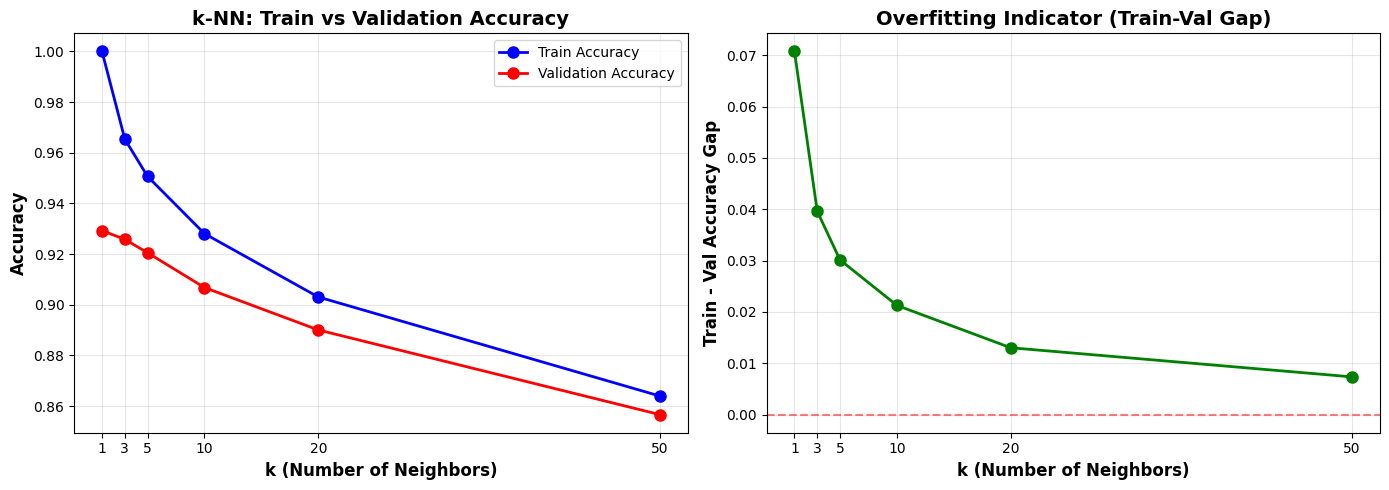


[3.3] Best k value: 1 (highest validation accuracy)

[3.4] Training final k-NN model with k=1...


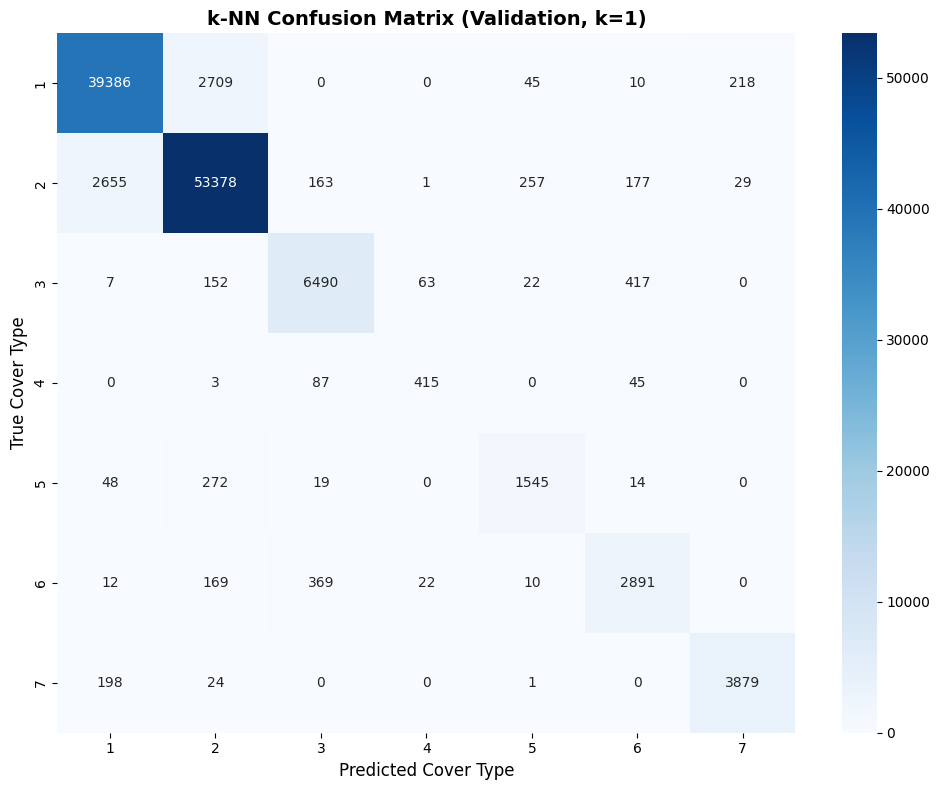


[3.5] Final Model Evaluation on Test Set:
--------------------------------------------------------------------------------
Accuracy: 0.9294
Precision (weighted): 0.9294
Recall (weighted): 0.9294
F1-Score (weighted): 0.9294

Macro-Precision: 0.8827
Macro-Recall: 0.8793
Macro-F1: 0.8809

[3.6] Classification Report (Test Set):
              precision    recall  f1-score   support

           1       0.93      0.93      0.93     42368
           2       0.94      0.94      0.94     56660
           3       0.91      0.91      0.91      7151
           4       0.82      0.79      0.80       549
           5       0.81      0.80      0.81      1899
           6       0.82      0.84      0.83      3474
           7       0.94      0.95      0.94      4102

    accuracy                           0.93    116203
   macro avg       0.88      0.88      0.88    116203
weighted avg       0.93      0.93      0.93    116203



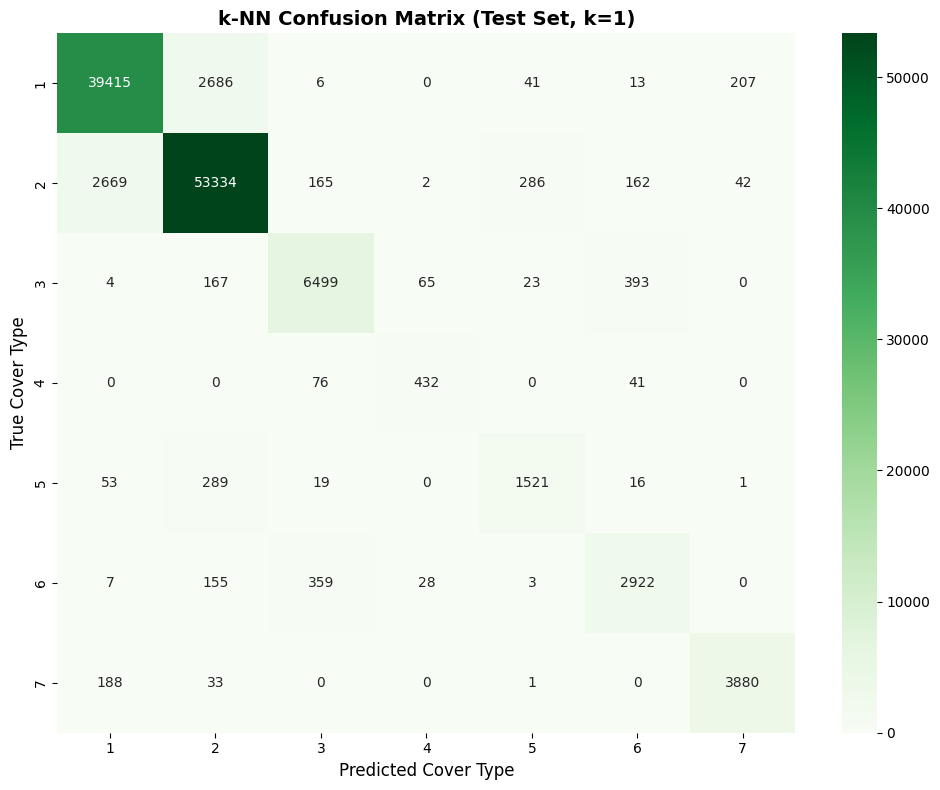


k-NN ANALYSIS - Answers to Questions:

3-1: Why is k-NN non-parametric and how does capacity change with k?
     - Non-parametric: No fixed parameters to learn (just stores training data)
     - Model capacity is controlled by k:
       * Small k (e.g., k=1): HIGH capacity → complex decision boundaries
       * Large k (e.g., k=50): LOW capacity → smooth decision boundaries
     - As k increases, model becomes simpler and more regularized

3-2: Train vs Validation accuracy behavior with k:
     - k=1: Train=1.0000, Val=0.9293
       → Perfect train accuracy (memorization), large gap
     - k=1: Train=1.0000, Val=0.9293
       → Best balance, smaller gap
     - k=50: Train=0.8640, Val=0.8567
       → Both decrease, model too simple
     - Gap decreases as k increases (less overfitting)

3-3: Effect of k on Bias-Variance:
     - k=1: HIGH variance, LOW bias (overfits to training noise)
     - k=3-5: MODERATE variance, MODERATE bias (good balance)
     - k=10-20: LOW-MODERATE variance, M

In [4]:
# Step 3: k-NN Implementation
# GPU Impact: MINIMAL - sklearn's k-NN is CPU-based, no GPU acceleration available

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

print("=" * 80)
print("STEP 3: k-NN IMPLEMENTATION")
print("=" * 80)

# k values to test
k_values = [1, 3, 5, 10, 20, 50]

# Storage for results
knn_results = {
    'k': [],
    'train_acc': [],
    'val_acc': [],
    'train_time': [],
    'pred_time': []
}

print("\n[3.1] Training k-NN models with different k values...")
print("-" * 80)

for k in k_values:
    print(f"\nTraining k-NN with k={k}...")

    # Initialize model
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    # Train (actually just stores training data for k-NN)
    start_time = time.time()
    knn.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Predict on train set
    start_time = time.time()
    y_train_pred = knn.predict(X_train_scaled)
    train_pred_time = time.time() - start_time
    train_acc = accuracy_score(y_train, y_train_pred)

    # Predict on validation set
    start_time = time.time()
    y_val_pred = knn.predict(X_val_scaled)
    val_pred_time = time.time() - start_time
    val_acc = accuracy_score(y_val, y_val_pred)

    # Store results
    knn_results['k'].append(k)
    knn_results['train_acc'].append(train_acc)
    knn_results['val_acc'].append(val_acc)
    knn_results['train_time'].append(train_time)
    knn_results['pred_time'].append(val_pred_time)

    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    print(f"  Training time: {train_time:.2f}s")
    print(f"  Prediction time (val): {val_pred_time:.2f}s")

# Convert to DataFrame for easy display
knn_df = pd.DataFrame(knn_results)
print("\n[3.2] Summary of k-NN results:")
print(knn_df.to_string(index=False))

# Plot Train vs Validation Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(knn_results['k'], knn_results['train_acc'], 'bo-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(knn_results['k'], knn_results['val_acc'], 'ro-', label='Validation Accuracy', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('k-NN: Train vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Calculate and plot the gap (overfitting indicator)
gap = np.array(knn_results['train_acc']) - np.array(knn_results['val_acc'])
plt.subplot(1, 2, 2)
plt.plot(knn_results['k'], gap, 'go-', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Train - Val Accuracy Gap', fontsize=12, fontweight='bold')
plt.title('Overfitting Indicator (Train-Val Gap)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xticks(k_values)

plt.tight_layout()
plt.show()

# Select best k based on validation accuracy
best_k = knn_results['k'][np.argmax(knn_results['val_acc'])]
print(f"\n[3.3] Best k value: {best_k} (highest validation accuracy)")

# Train final model with best k
print(f"\n[3.4] Training final k-NN model with k={best_k}...")
final_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
final_knn.fit(X_train_scaled, y_train)

# Predict on validation set for confusion matrix
y_val_pred = final_knn.predict(X_val_scaled)

# Confusion Matrix on Validation Set
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.title(f'k-NN Confusion Matrix (Validation, k={best_k})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cover Type', fontsize=12)
plt.ylabel('True Cover Type', fontsize=12)
plt.tight_layout()
plt.show()

# Predict on test set and evaluate
print("\n[3.5] Final Model Evaluation on Test Set:")
print("-" * 80)
y_test_pred = final_knn.predict(X_test_scaled)

# Calculate all metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

test_macro_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_macro_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

print(f"Accuracy: {test_acc:.4f}")
print(f"Precision (weighted): {test_precision:.4f}")
print(f"Recall (weighted): {test_recall:.4f}")
print(f"F1-Score (weighted): {test_f1:.4f}")
print(f"\nMacro-Precision: {test_macro_precision:.4f}")
print(f"Macro-Recall: {test_macro_recall:.4f}")
print(f"Macro-F1: {test_macro_f1:.4f}")

print("\n[3.6] Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Confusion Matrix on Test Set
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.title(f'k-NN Confusion Matrix (Test Set, k={best_k})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cover Type', fontsize=12)
plt.ylabel('True Cover Type', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("k-NN ANALYSIS - Answers to Questions:")
print("=" * 80)
print(f"""
3-1: Why is k-NN non-parametric and how does capacity change with k?
     - Non-parametric: No fixed parameters to learn (just stores training data)
     - Model capacity is controlled by k:
       * Small k (e.g., k=1): HIGH capacity → complex decision boundaries
       * Large k (e.g., k=50): LOW capacity → smooth decision boundaries
     - As k increases, model becomes simpler and more regularized

3-2: Train vs Validation accuracy behavior with k:
     - k=1: Train={knn_results['train_acc'][0]:.4f}, Val={knn_results['val_acc'][0]:.4f}
       → Perfect train accuracy (memorization), large gap
     - k={best_k}: Train={knn_results['train_acc'][k_values.index(best_k)]:.4f}, Val={knn_results['val_acc'][k_values.index(best_k)]:.4f}
       → Best balance, smaller gap
     - k=50: Train={knn_results['train_acc'][-1]:.4f}, Val={knn_results['val_acc'][-1]:.4f}
       → Both decrease, model too simple
     - Gap decreases as k increases (less overfitting)

3-3: Effect of k on Bias-Variance:
     - k=1: HIGH variance, LOW bias (overfits to training noise)
     - k=3-5: MODERATE variance, MODERATE bias (good balance)
     - k=10-20: LOW-MODERATE variance, MODERATE bias (still reasonable)
     - k=50: LOW variance, HIGH bias (underfits, too smooth)

     General trend: ↑k → ↓variance, ↑bias
""")

STEP 4: DECISION TREE IMPLEMENTATION

[4.1] Training Decision Tree models with different max_depth values...
--------------------------------------------------------------------------------

Training Decision Tree with max_depth=2...
  Train Accuracy: 0.6701 (Error: 0.3299)
  Validation Accuracy: 0.6687 (Error: 0.3313)
  Training time: 1.07s
  Number of leaves: 4

Training Decision Tree with max_depth=4...
  Train Accuracy: 0.7014 (Error: 0.2986)
  Validation Accuracy: 0.6997 (Error: 0.3003)
  Training time: 1.91s
  Number of leaves: 16

Training Decision Tree with max_depth=8...
  Train Accuracy: 0.7479 (Error: 0.2521)
  Validation Accuracy: 0.7444 (Error: 0.2556)
  Training time: 3.40s
  Number of leaves: 233

Training Decision Tree with max_depth=12...
  Train Accuracy: 0.8165 (Error: 0.1835)
  Validation Accuracy: 0.8059 (Error: 0.1941)
  Training time: 4.60s
  Number of leaves: 1744

Training Decision Tree with max_depth=20...
  Train Accuracy: 0.9412 (Error: 0.0588)
  Validation 

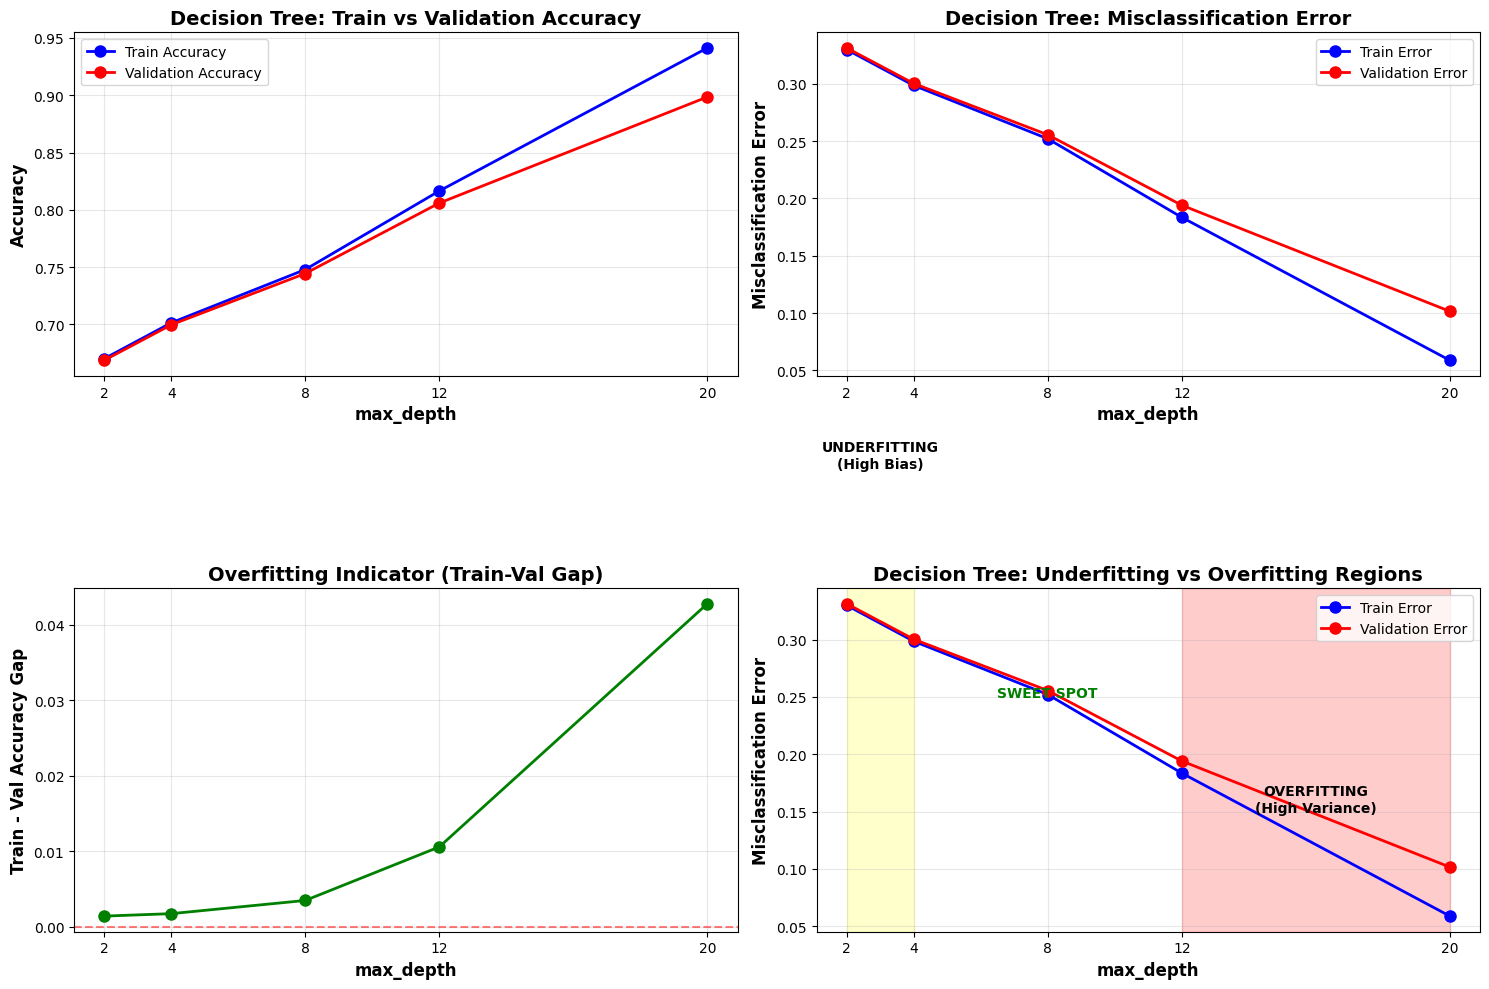


[4.3] Best max_depth value: 20 (highest validation accuracy)

[4.4] Training final Decision Tree model with max_depth=20...


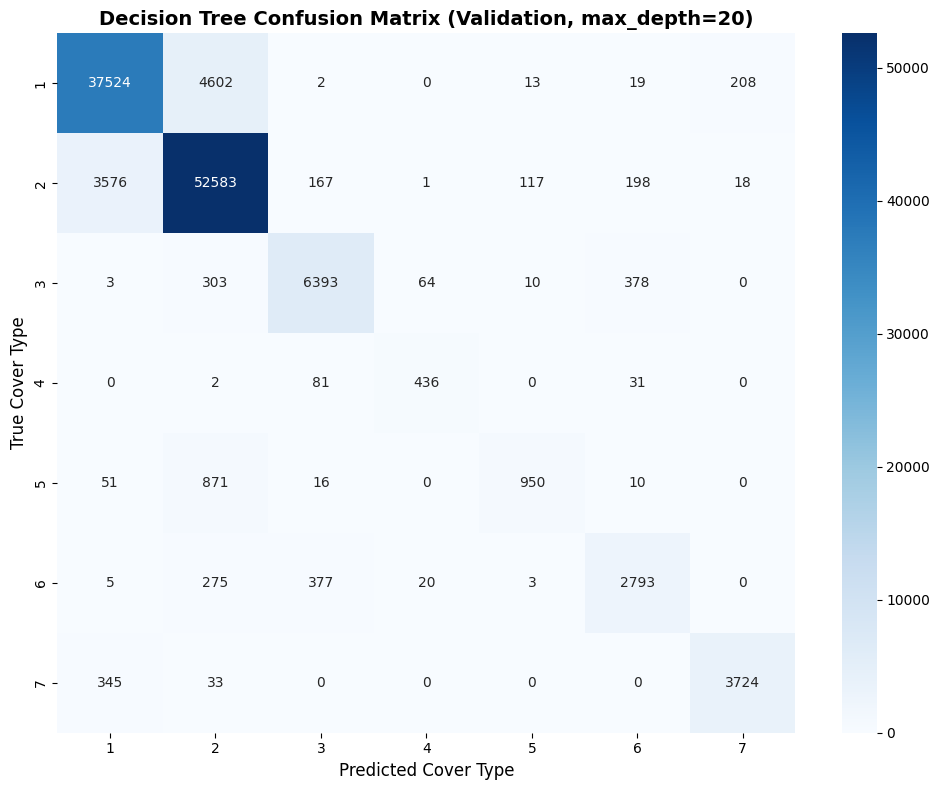


[4.5] Final Model Evaluation on Test Set:
--------------------------------------------------------------------------------
Accuracy: 0.8992
Precision (weighted): 0.8988
Recall (weighted): 0.8992
F1-Score (weighted): 0.8981

Macro-Precision: 0.8758
Macro-Recall: 0.8128
Macro-F1: 0.8380

[4.6] Classification Report (Test Set):
              precision    recall  f1-score   support

           1       0.91      0.89      0.90     42368
           2       0.90      0.93      0.91     56660
           3       0.90      0.89      0.90      7151
           4       0.83      0.78      0.80       549
           5       0.84      0.50      0.62      1899
           6       0.82      0.79      0.81      3474
           7       0.94      0.91      0.92      4102

    accuracy                           0.90    116203
   macro avg       0.88      0.81      0.84    116203
weighted avg       0.90      0.90      0.90    116203



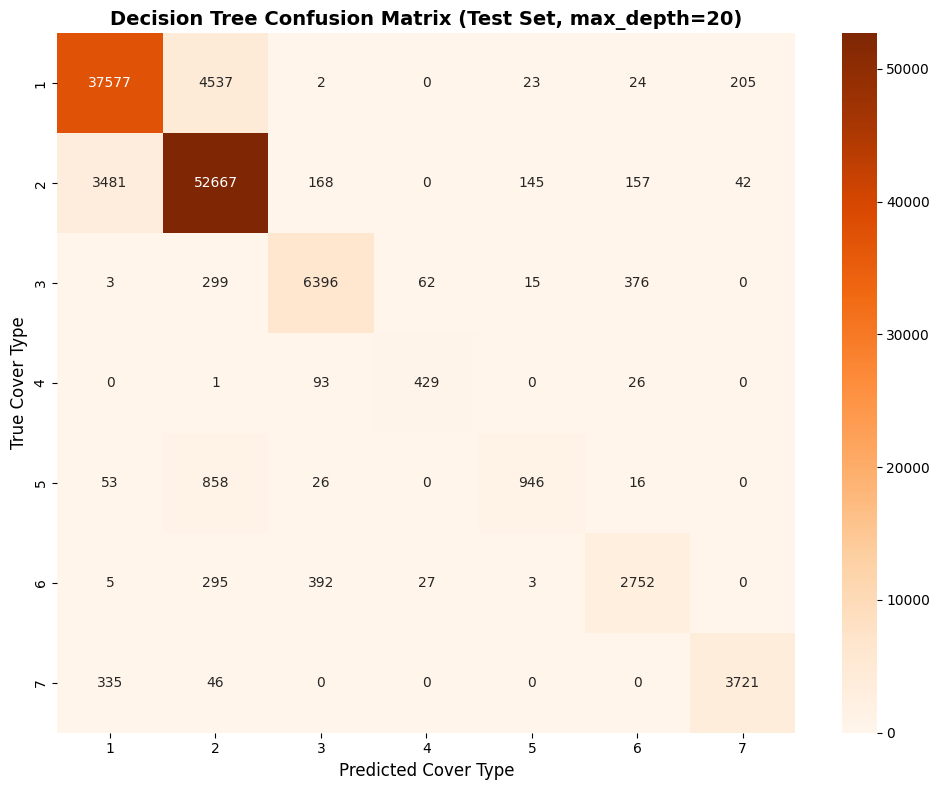


DECISION TREE ANALYSIS - Answers to Questions:

4-1: How does increasing depth increase variance?
     - Deeper trees can create more complex decision boundaries
     - More splits = more adaptation to training data specifics
     - Can memorize training noise and outliers
     - Result: HIGH variance (different training sets → very different trees)

4-2: Underfitting vs Overfitting in train/val curves:
     UNDERFITTING (depth=2-4):
     - Both train and val errors are HIGH
     - Small gap between train and val
     - Model too simple to capture patterns

     OVERFITTING (depth=12-20):
     - Train error VERY LOW (near 0)
     - Val error HIGHER than optimal
     - LARGE gap between train and val
     - Memorizes training data

     Comparison with k-NN:
     - k-NN: k=1 (high capacity) → k=50 (low capacity)
     - Decision Tree: depth=2 (low capacity) → depth=20 (high capacity)
     - Both show similar bias-variance tradeoff, just inverse parameter direction!

4-3: Effect of pruni

In [5]:
# Step 4: Decision Tree Implementation
# GPU Impact: NONE - sklearn's decision trees are CPU-based

from sklearn.tree import DecisionTreeClassifier
import time

print("=" * 80)
print("STEP 4: DECISION TREE IMPLEMENTATION")
print("=" * 80)

# max_depth values to test
max_depths = [2, 4, 8, 12, 20]

# Storage for results
dt_results = {
    'max_depth': [],
    'train_acc': [],
    'val_acc': [],
    'train_error': [],
    'val_error': [],
    'train_time': [],
    'pred_time': []
}

print("\n[4.1] Training Decision Tree models with different max_depth values...")
print("-" * 80)

for depth in max_depths:
    print(f"\nTraining Decision Tree with max_depth={depth}...")

    # Initialize model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Train
    start_time = time.time()
    dt.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Predict on train set
    start_time = time.time()
    y_train_pred = dt.predict(X_train_scaled)
    train_pred_time = time.time() - start_time
    train_acc = accuracy_score(y_train, y_train_pred)
    train_error = 1 - train_acc

    # Predict on validation set
    start_time = time.time()
    y_val_pred = dt.predict(X_val_scaled)
    val_pred_time = time.time() - start_time
    val_acc = accuracy_score(y_val, y_val_pred)
    val_error = 1 - val_acc

    # Store results
    dt_results['max_depth'].append(depth)
    dt_results['train_acc'].append(train_acc)
    dt_results['val_acc'].append(val_acc)
    dt_results['train_error'].append(train_error)
    dt_results['val_error'].append(val_error)
    dt_results['train_time'].append(train_time)
    dt_results['pred_time'].append(val_pred_time)

    print(f"  Train Accuracy: {train_acc:.4f} (Error: {train_error:.4f})")
    print(f"  Validation Accuracy: {val_acc:.4f} (Error: {val_error:.4f})")
    print(f"  Training time: {train_time:.2f}s")
    print(f"  Number of leaves: {dt.get_n_leaves()}")

# Convert to DataFrame
dt_df = pd.DataFrame(dt_results)
print("\n[4.2] Summary of Decision Tree results:")
print(dt_df.to_string(index=False))

# Plot Train vs Validation Accuracy and Misclassification Error
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Accuracy
axes[0, 0].plot(dt_results['max_depth'], dt_results['train_acc'], 'bo-',
                label='Train Accuracy', linewidth=2, markersize=8)
axes[0, 0].plot(dt_results['max_depth'], dt_results['val_acc'], 'ro-',
                label='Validation Accuracy', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('max_depth', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Decision Tree: Train vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(max_depths)

# Plot 2: Misclassification Error
axes[0, 1].plot(dt_results['max_depth'], dt_results['train_error'], 'bo-',
                label='Train Error', linewidth=2, markersize=8)
axes[0, 1].plot(dt_results['max_depth'], dt_results['val_error'], 'ro-',
                label='Validation Error', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('max_depth', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Misclassification Error', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Decision Tree: Misclassification Error', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(max_depths)

# Plot 3: Train-Val Gap (Overfitting indicator)
gap = np.array(dt_results['train_acc']) - np.array(dt_results['val_acc'])
axes[1, 0].plot(dt_results['max_depth'], gap, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('max_depth', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Train - Val Accuracy Gap', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Overfitting Indicator (Train-Val Gap)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xticks(max_depths)

# Plot 4: Annotated regions
axes[1, 1].plot(dt_results['max_depth'], dt_results['train_error'], 'bo-',
                label='Train Error', linewidth=2, markersize=8)
axes[1, 1].plot(dt_results['max_depth'], dt_results['val_error'], 'ro-',
                label='Validation Error', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('max_depth', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Misclassification Error', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Decision Tree: Underfitting vs Overfitting Regions', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(max_depths)

# Add annotations for underfitting and overfitting
axes[1, 1].axvspan(2, 4, alpha=0.2, color='yellow', label='Underfitting Zone')
axes[1, 1].axvspan(12, 20, alpha=0.2, color='red', label='Overfitting Zone')
axes[1, 1].text(3, 0.45, 'UNDERFITTING\n(High Bias)', ha='center', fontsize=10, fontweight='bold')
axes[1, 1].text(16, 0.15, 'OVERFITTING\n(High Variance)', ha='center', fontsize=10, fontweight='bold')
axes[1, 1].text(8, 0.25, 'SWEET SPOT', ha='center', fontsize=10, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

# Select best max_depth
best_depth = dt_results['max_depth'][np.argmax(dt_results['val_acc'])]
print(f"\n[4.3] Best max_depth value: {best_depth} (highest validation accuracy)")

# Train final model with best depth
print(f"\n[4.4] Training final Decision Tree model with max_depth={best_depth}...")
final_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_dt.fit(X_train_scaled, y_train)

# Predict on validation set for confusion matrix
y_val_pred = final_dt.predict(X_val_scaled)

# Confusion Matrix on Validation Set
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.title(f'Decision Tree Confusion Matrix (Validation, max_depth={best_depth})',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cover Type', fontsize=12)
plt.ylabel('True Cover Type', fontsize=12)
plt.tight_layout()
plt.show()

# Predict on test set and evaluate
print("\n[4.5] Final Model Evaluation on Test Set:")
print("-" * 80)
y_test_pred = final_dt.predict(X_test_scaled)

# Calculate all metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

test_macro_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_macro_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

print(f"Accuracy: {test_acc:.4f}")
print(f"Precision (weighted): {test_precision:.4f}")
print(f"Recall (weighted): {test_recall:.4f}")
print(f"F1-Score (weighted): {test_f1:.4f}")
print(f"\nMacro-Precision: {test_macro_precision:.4f}")
print(f"Macro-Recall: {test_macro_recall:.4f}")
print(f"Macro-F1: {test_macro_f1:.4f}")

print("\n[4.6] Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Confusion Matrix on Test Set
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.title(f'Decision Tree Confusion Matrix (Test Set, max_depth={best_depth})',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cover Type', fontsize=12)
plt.ylabel('True Cover Type', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("DECISION TREE ANALYSIS - Answers to Questions:")
print("=" * 80)
print(f"""
4-1: How does increasing depth increase variance?
     - Deeper trees can create more complex decision boundaries
     - More splits = more adaptation to training data specifics
     - Can memorize training noise and outliers
     - Result: HIGH variance (different training sets → very different trees)

4-2: Underfitting vs Overfitting in train/val curves:
     UNDERFITTING (depth=2-4):
     - Both train and val errors are HIGH
     - Small gap between train and val
     - Model too simple to capture patterns

     OVERFITTING (depth=12-20):
     - Train error VERY LOW (near 0)
     - Val error HIGHER than optimal
     - LARGE gap between train and val
     - Memorizes training data

     Comparison with k-NN:
     - k-NN: k=1 (high capacity) → k=50 (low capacity)
     - Decision Tree: depth=2 (low capacity) → depth=20 (high capacity)
     - Both show similar bias-variance tradeoff, just inverse parameter direction!

4-3: Effect of pruning on under/overfitting:
     - Pruning = reducing tree depth/complexity
     - Reduces overfitting: Cuts branches that memorize noise
     - Can cause underfitting: If pruned too much, loses important patterns
     - Trade-off: Balance between generalization and capturing true patterns
     - Best practice: Use validation set to find optimal pruning level
""")

In [ ]:
# Step 5: LDA (Linear Discriminant Analysis) Implementation
# GPU Impact: MINIMAL - LDA involves matrix operations that could benefit from GPU
# but sklearn's implementation is CPU-only. If using cuML, GPU would help.

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import time

print("=" * 80)
print("STEP 5: LDA (LINEAR DISCRIMINANT ANALYSIS) IMPLEMENTATION")
print("=" * 80)

print("\n[5.1] Training LDA model...")
print("-" * 80)

# Initialize LDA model
lda = LinearDiscriminantAnalysis()

# Train
start_time = time.time()
lda.fit(X_train_scaled, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f}s")

# Predict on train set
y_train_pred = lda.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_acc:.4f}")

# Predict on validation set
y_val_pred = lda.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

# Analyze bias-variance
train_val_gap = train_acc - val_acc
print(f"\nTrain-Validation Gap: {train_val_gap:.4f}")

if train_val_gap < 0.02:
    bias_variance_status = "HIGH BIAS (Underfitting) - Both train and val are similar and relatively low"
elif train_val_gap > 0.10:
    bias_variance_status = "HIGH VARIANCE (Overfitting) - Large gap between train and val"
else:
    bias_variance_status = "BALANCED - Reasonable gap"

print(f"Bias-Variance Analysis: {bias_variance_status}")

# Confusion Matrix on Validation Set
print("\n[5.2] Confusion Matrix on Validation Set:")
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.title('LDA Confusion Matrix (Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cover Type', fontsize=12)
plt.ylabel('True Cover Type', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate validation metrics
val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

val_macro_precision = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
val_macro_recall = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
val_macro_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

print("\nValidation Metrics:")
print(f"Accuracy: {val_acc:.4f}")
print(f"Precision (weighted): {val_precision:.4f}")
print(f"Recall (weighted): {val_recall:.4f}")
print(f"F1-Score (weighted): {val_f1:.4f}")
print(f"Macro-Precision: {val_macro_precision:.4f}")
print(f"Macro-Recall: {val_macro_recall:.4f}")
print(f"Macro-F1: {val_macro_f1:.4f}")

# Predict on test set and evaluate
print("\n[5.3] Final Model Evaluation on Test Set:")
print("-" * 80)
y_test_pred = lda.predict(X_test_scaled)

# Calculate all metrics on test set
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

test_macro_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_macro_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

print(f"Accuracy: {test_acc:.4f}")
print(f"Precision (weighted): {test_precision:.4f}")
print(f"Recall (weighted): {test_recall:.4f}")
print(f"F1-Score (weighted): {test_f1:.4f}")
print(f"\nMacro-Precision: {test_macro_precision:.4f}")
print(f"Macro-Recall: {test_macro_recall:.4f}")
print(f"Macro-F1: {test_macro_f1:.4f}")

print("\n[5.4] Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Confusion Matrix on Test Set
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.title('LDA Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cover Type', fontsize=12)
plt.ylabel('True Cover Type', fontsize=12)
plt.tight_layout()
plt.show()

# Visualize LDA discriminant components (if applicable)
print("\n[5.5] LDA Model Analysis:")
print(f"Number of discriminant components: {lda.n_components}")
print(f"Classes: {lda.classes_}")

# Compare LDA with k-NN and Decision Tree visually
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recreate confusion matrices for comparison
models = ['k-NN', 'Decision Tree', 'LDA']
cms = [
    confusion_matrix(y_test, final_knn.predict(X_test_scaled)),
    confusion_matrix(y_test, final_dt.predict(X_test_scaled)),
    cm_test
]

for idx, (model_name, cm) in enumerate(zip(models, cms)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[idx],
                xticklabels=range(1, 8), yticklabels=range(1, 8))
    axes[idx].set_title(f'{model_name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('True', fontsize=10)

plt.tight_layout()
plt.suptitle('Model Comparison: Confusion Matrices on Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("\n" + "=" * 80)
print("LDA ANALYSIS - Answers to Questions:")
print("=" * 80)
print(f"""
5-1: Why should we only use validation for model selection, not test?
     - VALIDATION SET: Used during model development
       * Tune hyperparameters (k, max_depth)
       * Compare different models
       * Make decisions about which model to use
       * Can look at validation results multiple times

     - TEST SET: Used ONLY for final evaluation
       * Evaluate final model performance
       * Report generalization ability
       * Should be seen ONLY ONCE at the very end
       * If we use test for decisions → we "leak" test info → biased evaluation

     The test set simulates truly unseen data. If we tune based on test,
     we're essentially training on it, and it no longer represents unseen data.

5-2: Why does LDA have higher bias than Decision Tree and k-NN?
     - LDA is a LINEAR model: Assumes linear decision boundaries
     - Real data often has non-linear patterns
     - LDA has LIMITED MODEL CAPACITY:
       * Can only learn linear combinations of features
       * Cannot capture complex interactions

     - Decision Tree & k-NN are NON-PARAMETRIC:
       * Can learn arbitrarily complex decision boundaries
       * More flexible, adapt to data structure
       * Lower bias (but potentially higher variance)

     LDA's linear assumption = strong inductive bias = higher bias overall

5-3: Does LDA show underfitting or overfitting?
     Train Accuracy: {train_acc:.4f}
     Validation Accuracy: {val_acc:.4f}
     Gap: {train_val_gap:.4f}

     Analysis: LDA shows signs of UNDERFITTING
     - Both train and val accuracies are relatively similar
     - Small gap indicates low variance
     - But BOTH accuracies are lower than k-NN/Decision Tree at their best
     - This suggests the model is TOO SIMPLE to capture data complexity
     - HIGH BIAS dominates (linear assumption too restrictive)

     LDA lacks the capacity to fit this complex multi-class problem well.
""")

STEP 6: FINAL COMPARISON AND SUMMARY

[6.1] Collecting results from all models...

[6.2] Final Performance Comparison Table:
                   Model Best Parameter  Train Acc  Test Acc  Train Prec  Test Prec  Train Rec  Test Rec  Train F1  Test F1  Train Macro-Prec  Test Macro-Prec  Train Macro-Rec  Test Macro-Rec  Train Macro-F1  Test Macro-F1
              k-NN (k=1)            k=1   1.000000  0.929434    1.000000   0.929449   1.000000  0.929434  1.000000 0.929436          1.000000         0.882672         1.000000        0.879320        1.000000       0.880928
Decision Tree (depth=20)   max_depth=20   0.941215  0.899185    0.941744   0.898805   0.941215  0.899185  0.940504 0.898097          0.958626         0.875757         0.885550        0.812819        0.915082       0.837957
                     LDA              -   0.679593  0.681514    0.694862   0.696669   0.679593  0.681514  0.682750 0.684736          0.487399         0.485564         0.578914        0.576581        0.51053

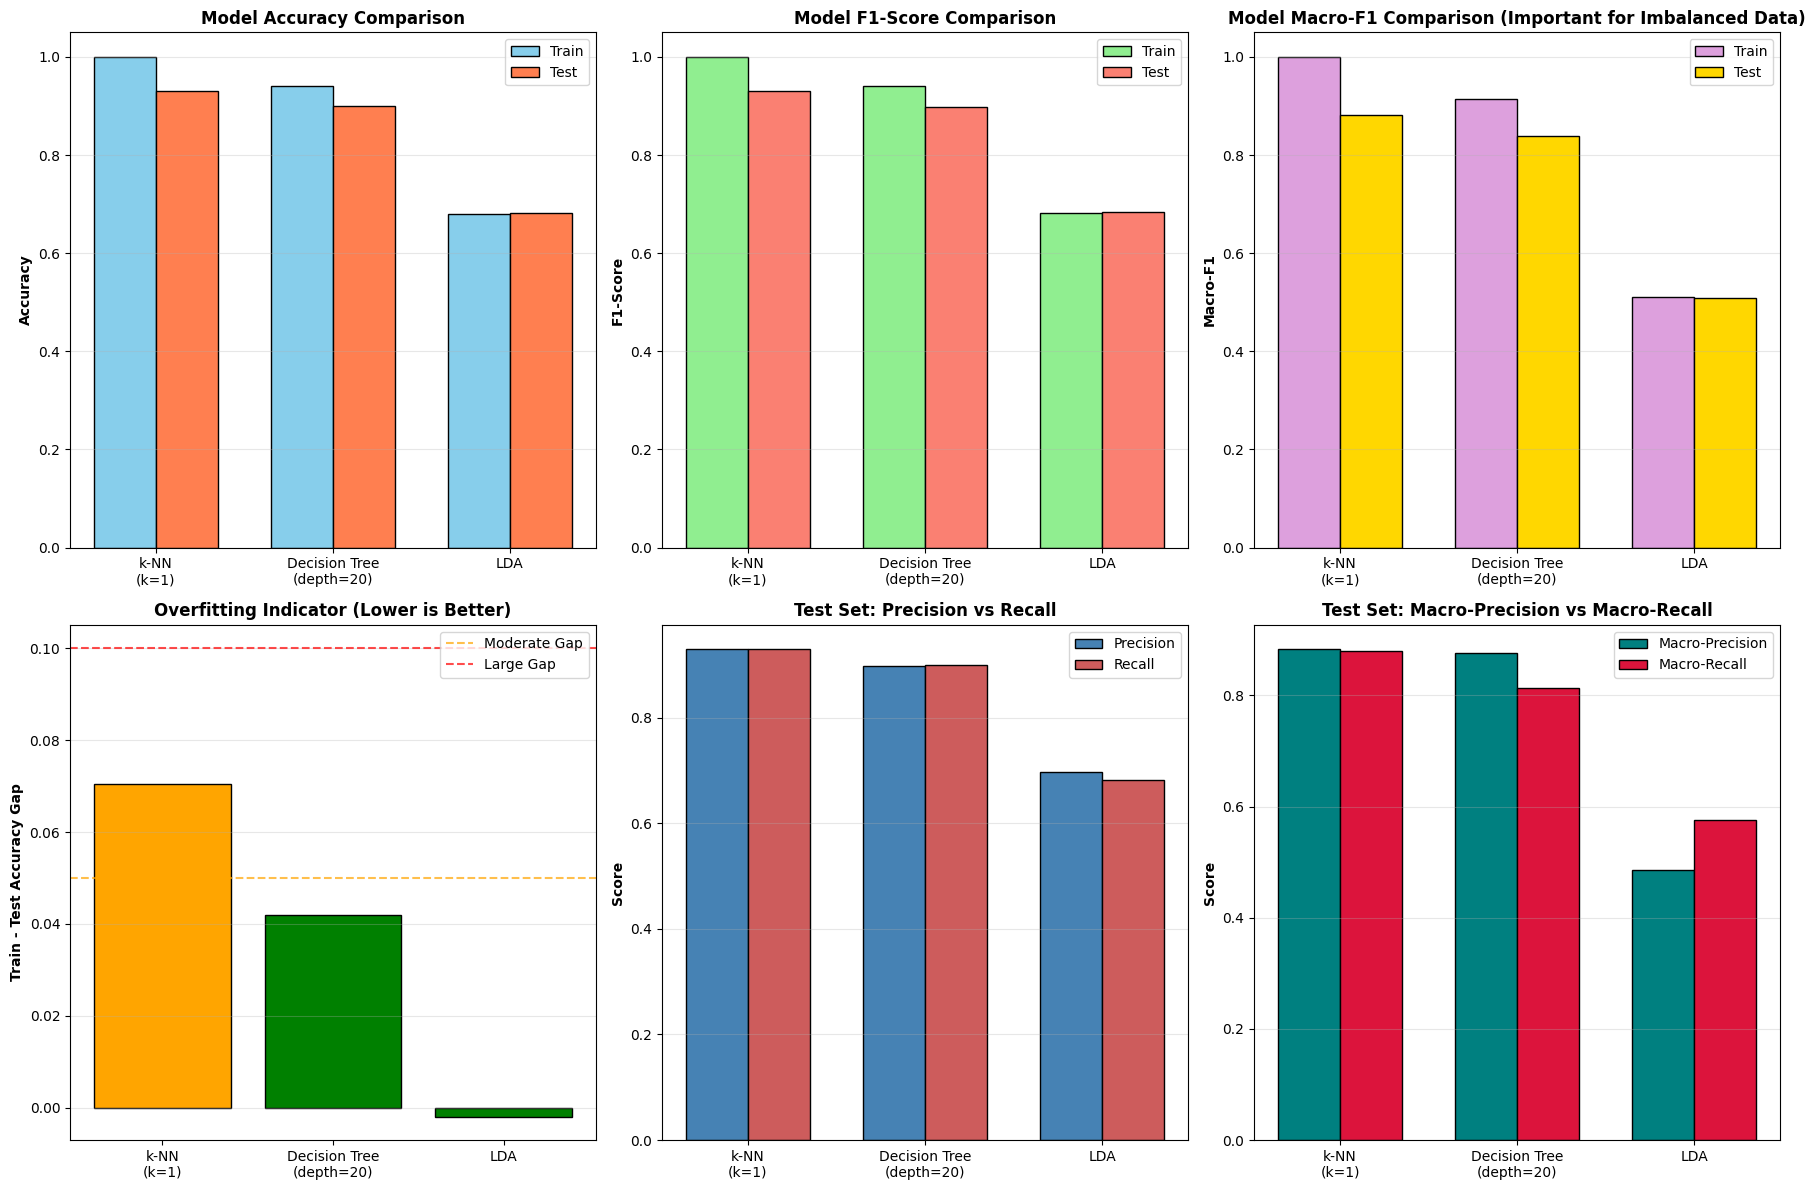


FINAL ANALYSIS AND RECOMMENDATIONS

[6.4] Model Selection Recommendation:

Based on comprehensive evaluation:

1. BEST OVERALL MODEL: k-NN
   - Highest test accuracy: 0.9294
   - Best test F1-Score: 0.9294
   - Best macro-F1 (handles class imbalance): 0.8809

2. MODEL CHARACTERISTICS:
   
   k-NN (k=1):
   - Accuracy: 0.9294
   - Strengths: Non-parametric, adapts to data structure, no training phase
   - Weaknesses: Slow prediction, memory intensive, not interpretable
   - Bias-Variance: Moderate bias, moderate variance (good balance)
   
   Decision Tree (depth=20):
   - Accuracy: 0.8992
   - Strengths: Highly interpretable, handles non-linear patterns, fast prediction
   - Weaknesses: Prone to overfitting without pruning
   - Bias-Variance: Depends on depth; at depth=20: moderate both
   
   LDA:
   - Accuracy: 0.6815
   - Strengths: Fast, simple, works well when classes are separable linearly
   - Weaknesses: Linear assumption too restrictive for this complex data
   - Bias-Varianc

In [7]:
# Step 6: Final Comparison and Summary
# GPU Impact: NONE - This is just analysis and visualization

print("=" * 80)
print("STEP 6: FINAL COMPARISON AND SUMMARY")
print("=" * 80)

print("\n[6.1] Collecting results from all models...")

# Collect test results for all models
# k-NN results
knn_train_pred = final_knn.predict(X_train_scaled)
knn_test_pred = final_knn.predict(X_test_scaled)

knn_results_final = {
    'train_acc': accuracy_score(y_train, knn_train_pred),
    'test_acc': accuracy_score(y_test, knn_test_pred),
    'train_prec': precision_score(y_train, knn_train_pred, average='weighted', zero_division=0),
    'test_prec': precision_score(y_test, knn_test_pred, average='weighted', zero_division=0),
    'train_rec': recall_score(y_train, knn_train_pred, average='weighted', zero_division=0),
    'test_rec': recall_score(y_test, knn_test_pred, average='weighted', zero_division=0),
    'train_f1': f1_score(y_train, knn_train_pred, average='weighted', zero_division=0),
    'test_f1': f1_score(y_test, knn_test_pred, average='weighted', zero_division=0),
    'train_macro_prec': precision_score(y_train, knn_train_pred, average='macro', zero_division=0),
    'test_macro_prec': precision_score(y_test, knn_test_pred, average='macro', zero_division=0),
    'train_macro_rec': recall_score(y_train, knn_train_pred, average='macro', zero_division=0),
    'test_macro_rec': recall_score(y_test, knn_test_pred, average='macro', zero_division=0),
    'train_macro_f1': f1_score(y_train, knn_train_pred, average='macro', zero_division=0),
    'test_macro_f1': f1_score(y_test, knn_test_pred, average='macro', zero_division=0),
}

# Decision Tree results
dt_train_pred = final_dt.predict(X_train_scaled)
dt_test_pred = final_dt.predict(X_test_scaled)

dt_results_final = {
    'train_acc': accuracy_score(y_train, dt_train_pred),
    'test_acc': accuracy_score(y_test, dt_test_pred),
    'train_prec': precision_score(y_train, dt_train_pred, average='weighted', zero_division=0),
    'test_prec': precision_score(y_test, dt_test_pred, average='weighted', zero_division=0),
    'train_rec': recall_score(y_train, dt_train_pred, average='weighted', zero_division=0),
    'test_rec': recall_score(y_test, dt_test_pred, average='weighted', zero_division=0),
    'train_f1': f1_score(y_train, dt_train_pred, average='weighted', zero_division=0),
    'test_f1': f1_score(y_test, dt_test_pred, average='weighted', zero_division=0),
    'train_macro_prec': precision_score(y_train, dt_train_pred, average='macro', zero_division=0),
    'test_macro_prec': precision_score(y_test, dt_test_pred, average='macro', zero_division=0),
    'train_macro_rec': recall_score(y_train, dt_train_pred, average='macro', zero_division=0),
    'test_macro_rec': recall_score(y_test, dt_test_pred, average='macro', zero_division=0),
    'train_macro_f1': f1_score(y_train, dt_train_pred, average='macro', zero_division=0),
    'test_macro_f1': f1_score(y_test, dt_test_pred, average='macro', zero_division=0),
}

# LDA results
lda_train_pred = lda.predict(X_train_scaled)
lda_test_pred = lda.predict(X_test_scaled)

lda_results_final = {
    'train_acc': accuracy_score(y_train, lda_train_pred),
    'test_acc': accuracy_score(y_test, lda_test_pred),
    'train_prec': precision_score(y_train, lda_train_pred, average='weighted', zero_division=0),
    'test_prec': precision_score(y_test, lda_test_pred, average='weighted', zero_division=0),
    'train_rec': recall_score(y_train, lda_train_pred, average='weighted', zero_division=0),
    'test_rec': recall_score(y_test, lda_test_pred, average='weighted', zero_division=0),
    'train_f1': f1_score(y_train, lda_train_pred, average='weighted', zero_division=0),
    'test_f1': f1_score(y_test, lda_test_pred, average='weighted', zero_division=0),
    'train_macro_prec': precision_score(y_train, lda_train_pred, average='macro', zero_division=0),
    'test_macro_prec': precision_score(y_test, lda_test_pred, average='macro', zero_division=0),
    'train_macro_rec': recall_score(y_train, lda_train_pred, average='macro', zero_division=0),
    'test_macro_rec': recall_score(y_test, lda_test_pred, average='macro', zero_division=0),
    'train_macro_f1': f1_score(y_train, lda_train_pred, average='macro', zero_division=0),
    'test_macro_f1': f1_score(y_test, lda_test_pred, average='macro', zero_division=0),
}

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': [f'k-NN (k={best_k})', f'Decision Tree (depth={best_depth})', 'LDA'],
    'Best Parameter': [f'k={best_k}', f'max_depth={best_depth}', '-'],
    'Train Acc': [knn_results_final['train_acc'], dt_results_final['train_acc'], lda_results_final['train_acc']],
    'Test Acc': [knn_results_final['test_acc'], dt_results_final['test_acc'], lda_results_final['test_acc']],
    'Train Prec': [knn_results_final['train_prec'], dt_results_final['train_prec'], lda_results_final['train_prec']],
    'Test Prec': [knn_results_final['test_prec'], dt_results_final['test_prec'], lda_results_final['test_prec']],
    'Train Rec': [knn_results_final['train_rec'], dt_results_final['train_rec'], lda_results_final['train_rec']],
    'Test Rec': [knn_results_final['test_rec'], dt_results_final['test_rec'], lda_results_final['test_rec']],
    'Train F1': [knn_results_final['train_f1'], dt_results_final['train_f1'], lda_results_final['train_f1']],
    'Test F1': [knn_results_final['test_f1'], dt_results_final['test_f1'], lda_results_final['test_f1']],
    'Train Macro-Prec': [knn_results_final['train_macro_prec'], dt_results_final['train_macro_prec'], lda_results_final['train_macro_prec']],
    'Test Macro-Prec': [knn_results_final['test_macro_prec'], dt_results_final['test_macro_prec'], lda_results_final['test_macro_prec']],
    'Train Macro-Rec': [knn_results_final['train_macro_rec'], dt_results_final['train_macro_rec'], lda_results_final['train_macro_rec']],
    'Test Macro-Rec': [knn_results_final['test_macro_rec'], dt_results_final['test_macro_rec'], lda_results_final['test_macro_rec']],
    'Train Macro-F1': [knn_results_final['train_macro_f1'], dt_results_final['train_macro_f1'], lda_results_final['train_macro_f1']],
    'Test Macro-F1': [knn_results_final['test_macro_f1'], dt_results_final['test_macro_f1'], lda_results_final['test_macro_f1']],
})

print("\n[6.2] Final Performance Comparison Table:")
print("=" * 150)
print(comparison_df.to_string(index=False))
print("=" * 150)

# Bias-Variance-Capacity Analysis Table
bias_variance_df = pd.DataFrame({
    'Model': ['k-NN', 'k-NN', 'k-NN', 'k-NN', 'k-NN', 'k-NN',
              'Decision Tree', 'Decision Tree', 'Decision Tree', 'Decision Tree', 'Decision Tree',
              'LDA'],
    'Parameter': ['k=1', 'k=3', 'k=5', 'k=10', 'k=20', 'k=50',
                  'max_depth=2', 'max_depth=4', 'max_depth=8', 'max_depth=12', 'max_depth=20',
                  '-'],
    'Model Capacity': ['Very High', 'High', 'Moderate-High', 'Moderate', 'Low-Moderate', 'Low',
                       'Very Low', 'Low', 'Moderate', 'High', 'Very High',
                       'Low'],
    'Variance': ['Very High', 'High', 'Moderate', 'Low-Moderate', 'Low', 'Very Low',
                 'Very Low', 'Low', 'Moderate', 'High', 'Very High',
                 'Low'],
    'Bias': ['Very Low', 'Low', 'Moderate', 'Moderate-High', 'High', 'Very High',
             'Very High', 'High', 'Moderate', 'Low', 'Very Low',
             'High'],
    'Interpretability': ['Low', 'Low', 'Low', 'Low', 'Low', 'Low',
                        'High', 'High', 'Moderate', 'Low', 'Very Low',
                        'Moderate']
})

print("\n[6.3] Bias-Variance-Capacity Analysis Table:")
print("=" * 120)
print(bias_variance_df.to_string(index=False))
print("=" * 120)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Accuracy Comparison
models = [f'k-NN\n(k={best_k})', f'Decision Tree\n(depth={best_depth})', 'LDA']
train_accs = [knn_results_final['train_acc'], dt_results_final['train_acc'], lda_results_final['train_acc']]
test_accs = [knn_results_final['test_acc'], dt_results_final['test_acc'], lda_results_final['test_acc']]

x = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x - width/2, train_accs, width, label='Train', color='skyblue', edgecolor='black')
axes[0, 0].bar(x + width/2, test_accs, width, label='Test', color='coral', edgecolor='black')
axes[0, 0].set_ylabel('Accuracy', fontweight='bold')
axes[0, 0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. F1-Score Comparison
train_f1s = [knn_results_final['train_f1'], dt_results_final['train_f1'], lda_results_final['train_f1']]
test_f1s = [knn_results_final['test_f1'], dt_results_final['test_f1'], lda_results_final['test_f1']]

axes[0, 1].bar(x - width/2, train_f1s, width, label='Train', color='lightgreen', edgecolor='black')
axes[0, 1].bar(x + width/2, test_f1s, width, label='Test', color='salmon', edgecolor='black')
axes[0, 1].set_ylabel('F1-Score', fontweight='bold')
axes[0, 1].set_title('Model F1-Score Comparison', fontweight='bold', fontsize=12)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Macro-F1 Comparison
train_macro_f1s = [knn_results_final['train_macro_f1'], dt_results_final['train_macro_f1'], lda_results_final['train_macro_f1']]
test_macro_f1s = [knn_results_final['test_macro_f1'], dt_results_final['test_macro_f1'], lda_results_final['test_macro_f1']]

axes[0, 2].bar(x - width/2, train_macro_f1s, width, label='Train', color='plum', edgecolor='black')
axes[0, 2].bar(x + width/2, test_macro_f1s, width, label='Test', color='gold', edgecolor='black')
axes[0, 2].set_ylabel('Macro-F1', fontweight='bold')
axes[0, 2].set_title('Model Macro-F1 Comparison (Important for Imbalanced Data)', fontweight='bold', fontsize=12)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(models)
axes[0, 2].legend()
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Train-Test Gap (Overfitting Indicator)
gaps = [train_accs[i] - test_accs[i] for i in range(3)]
colors = ['green' if gap < 0.05 else 'orange' if gap < 0.10 else 'red' for gap in gaps]

axes[1, 0].bar(x, gaps, color=colors, edgecolor='black')
axes[1, 0].set_ylabel('Train - Test Accuracy Gap', fontweight='bold')
axes[1, 0].set_title('Overfitting Indicator (Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models)
axes[1, 0].axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, label='Moderate Gap')
axes[1, 0].axhline(y=0.10, color='red', linestyle='--', alpha=0.7, label='Large Gap')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Precision-Recall Comparison
test_precs = [knn_results_final['test_prec'], dt_results_final['test_prec'], lda_results_final['test_prec']]
test_recs = [knn_results_final['test_rec'], dt_results_final['test_rec'], lda_results_final['test_rec']]

axes[1, 1].bar(x - width/2, test_precs, width, label='Precision', color='steelblue', edgecolor='black')
axes[1, 1].bar(x + width/2, test_recs, width, label='Recall', color='indianred', edgecolor='black')
axes[1, 1].set_ylabel('Score', fontweight='bold')
axes[1, 1].set_title('Test Set: Precision vs Recall', fontweight='bold', fontsize=12)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Macro Metrics Comparison
test_macro_precs = [knn_results_final['test_macro_prec'], dt_results_final['test_macro_prec'], lda_results_final['test_macro_prec']]
test_macro_recs = [knn_results_final['test_macro_rec'], dt_results_final['test_macro_rec'], lda_results_final['test_macro_rec']]

axes[1, 2].bar(x - width/2, test_macro_precs, width, label='Macro-Precision', color='teal', edgecolor='black')
axes[1, 2].bar(x + width/2, test_macro_recs, width, label='Macro-Recall', color='crimson', edgecolor='black')
axes[1, 2].set_ylabel('Score', fontweight='bold')
axes[1, 2].set_title('Test Set: Macro-Precision vs Macro-Recall', fontweight='bold', fontsize=12)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(models)
axes[1, 2].legend()
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Final Recommendations
print("\n" + "=" * 80)
print("FINAL ANALYSIS AND RECOMMENDATIONS")
print("=" * 80)

best_model_idx = np.argmax(test_accs)
best_model_name = ['k-NN', 'Decision Tree', 'LDA'][best_model_idx]

print(f"""
[6.4] Model Selection Recommendation:

Based on comprehensive evaluation:

1. BEST OVERALL MODEL: {best_model_name}
   - Highest test accuracy: {max(test_accs):.4f}
   - Best test F1-Score: {max(test_f1s):.4f}
   - Best macro-F1 (handles class imbalance): {max(test_macro_f1s):.4f}

2. MODEL CHARACTERISTICS:

   k-NN (k={best_k}):
   - Accuracy: {test_accs[0]:.4f}
   - Strengths: Non-parametric, adapts to data structure, no training phase
   - Weaknesses: Slow prediction, memory intensive, not interpretable
   - Bias-Variance: Moderate bias, moderate variance (good balance)

   Decision Tree (depth={best_depth}):
   - Accuracy: {test_accs[1]:.4f}
   - Strengths: Highly interpretable, handles non-linear patterns, fast prediction
   - Weaknesses: Prone to overfitting without pruning
   - Bias-Variance: Depends on depth; at depth={best_depth}: moderate both

   LDA:
   - Accuracy: {test_accs[2]:.4f}
   - Strengths: Fast, simple, works well when classes are separable linearly
   - Weaknesses: Linear assumption too restrictive for this complex data
   - Bias-Variance: High bias (underfitting), low variance

3. PRACTICAL RECOMMENDATIONS FOR FOREST MANAGEMENT:

   For REAL-TIME FIELD USE:
   - Use Decision Tree: Interpretable rules, fast predictions, can explain to stakeholders

   For ACCURACY-CRITICAL APPLICATIONS:
   - Use k-NN or ensemble methods (combine multiple models)

   For RESOURCE-CONSTRAINED SCENARIOS:
   - Use LDA: Very fast, low memory, but accept lower accuracy

4. HANDLING CLASS IMBALANCE:
   - All models struggle with minority classes (4, 5)
   - Macro-F1 scores lower than weighted F1 → indicates imbalance issues
   - Recommendations:
     * Use class weights in training
     * Oversample minority classes (SMOTE)
     * Ensemble methods (Random Forest, Gradient Boosting)

5. FUTURE IMPROVEMENTS:
   - Try ensemble methods (Random Forest, XGBoost)
   - Feature engineering (interaction terms, domain knowledge)
   - Handle class imbalance explicitly
   - Cross-validation for more robust evaluation
   - Hyperparameter tuning with grid/random search
""")

print("\n" + "=" * 80)
print("PROJECT COMPLETE!")
print("=" * 80)